In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv('data/data_mapping.csv', sep=',')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,Single,2nd phase - general contingent,5,Animation and Multimedia Design,Daytime,Secondary education,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,International student,1,Tourism,Daytime,Secondary education,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1st phase - general contingent,5,Communication Design,Daytime,Secondary education,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,2nd phase - general contingent,2,Journalism and Communication,Daytime,Secondary education,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,Over 23 years old,1,Social Service (evening),Evening,Secondary education,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [69]:
def value_counts(df, column):
    return df[column].value_counts()


def pivot(df, column, sort = 'Dropout'):
   return df.groupby([column, 'Status']).size().unstack(fill_value=0)

def plot_pivot(df, column, sort = 'Dropout'):
    pivot(df, column).sort_values(by=sort, ascending=True).plot(
        kind='barh',
        stacked=True,
        figsize=(10,8)
    )

    plt.title(f'Distribusi Status by {column}')
    plt.xlabel('Jumlah')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

def plot_percentatage(df, column, sort = 'Dropout'):
    pivot(df, column).div(pivot(df, column).sum(axis=1), axis=0).sort_values(by=sort, ascending=True).plot(
        kind='barh',
        stacked=True,
        figsize=(10,8)
    )

    plt.title(f'Proporsi Status by {column}')
    plt.xlabel('Persentase')
    plt.show()

In [78]:
target = "Course"

value_counts(df, target)

Course
Nursing                                 766
Management                              380
Social Service                          355
Veterinary Nursing                      337
Journalism and Communication            331
Advertising and Marketing Management    268
Management (evening)                    268
Tourism                                 252
Communication Design                    226
Animation and Multimedia Design         215
Social Service (evening)                215
Agronomy                                210
Basic Education                         192
Informatics Engineering                 170
Equinculture                            141
Oral Hygiene                             86
Biofuel Production Technologies          12
Name: count, dtype: int64

In [79]:
pivot(df, target).sort_values(by="Dropout", ascending=False)

Status,Dropout,Enrolled,Graduate
Course,,,
Management (evening),136,54,78
Management,134,108,138
Nursing,118,100,548
Journalism and Communication,101,34,196
Tourism,96,41,115
Advertising and Marketing Management,95,48,125
Informatics Engineering,92,64,14
Veterinary Nursing,90,75,172
Agronomy,86,37,87


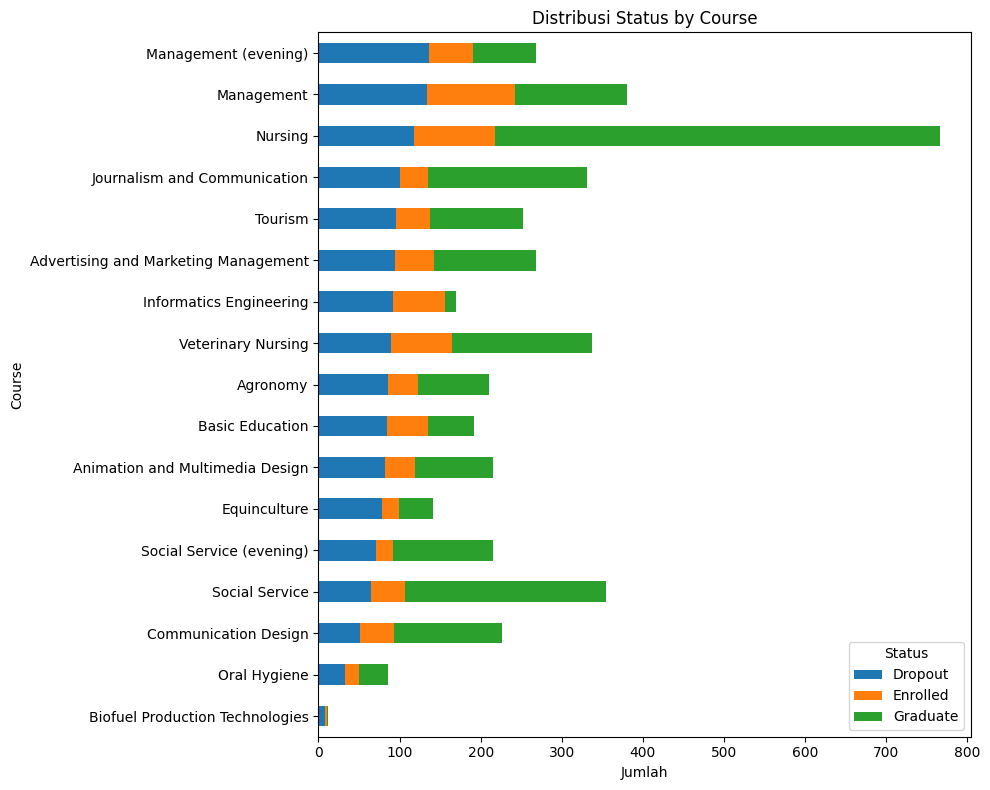

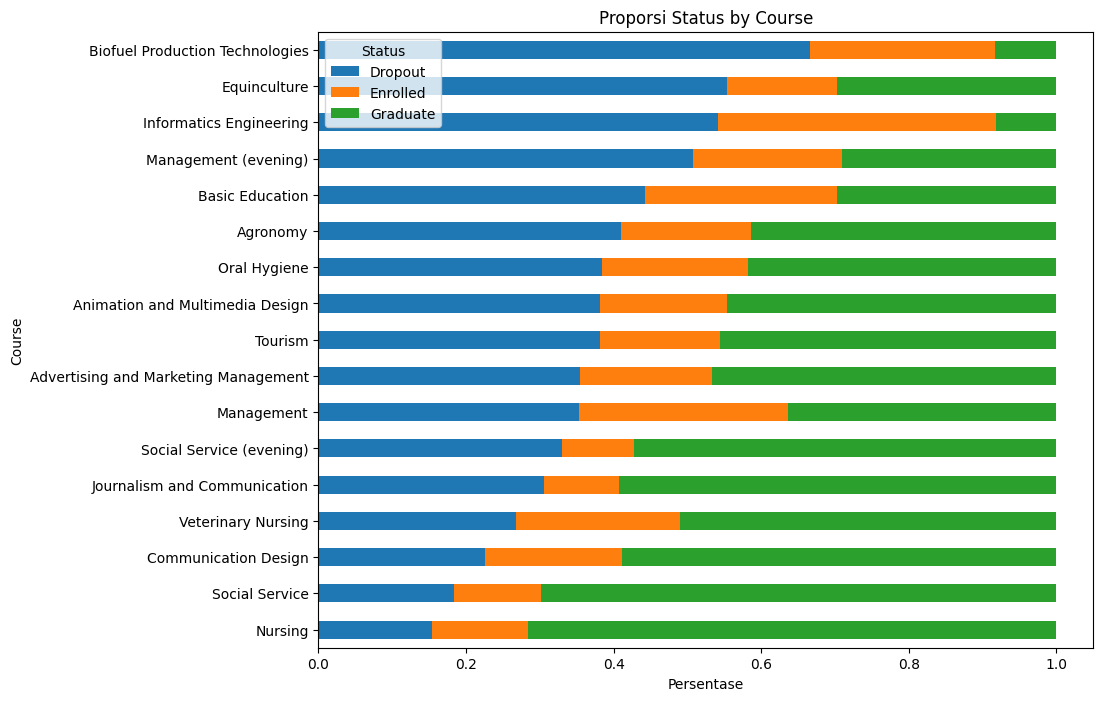

In [80]:
plot_pivot(df, target)
plot_percentatage(df, target)